# friends+ — Data Cleaning

Initial cleaning of `TMDB_tv_dataset_v3.csv` before synthesizing user archetypes.

1. Remove shows missing a title
2. Remove shows flagged as adult content

In [1]:
import pandas as pd

df = pd.read_csv("TMDB_tv_dataset_v3.csv", low_memory=False)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

Loaded 168,639 rows, 29 columns


## 1. Remove shows missing a title

In [2]:
before = len(df)
df = df[df["name"].notna()].reset_index(drop=True)
print(f"Removed {before - len(df)} shows with no title.")
print(f"{len(df):,} rows remain.")

Removed 5 shows with no title.
168,634 rows remain.


## 2. Remove adult shows

In [3]:
before = len(df)
df = df[df["adult"] == False].reset_index(drop=True)
print(f"Removed {before - len(df)} adult-flagged shows.")
print(f"{len(df):,} rows remain.")

Removed 2039 adult-flagged shows.
166,595 rows remain.


## Result

In [4]:
print(f"Final dataset: {len(df):,} rows, {df.shape[1]} columns")
df.head()

Final dataset: 166,595 rows, 29 columns


,id,name,number_of_seasons,number_of_episodes,original_language,vote_count,vote_average,overview,adult,backdrop_path,first_air_date,last_air_date,homepage,in_production,original_name,popularity,poster_path,type,status,tagline,genres,created_by,languages,networks,origin_country,spoken_languages,production_companies,production_countries,episode_run_time
0,1399,Game of Thrones,8,73,en,21857,8.442,Seven noble families fight for control of the ...,False,/2OMB0ynKlyIenMJWI2Dy9IWT4c.jpg,2011-04-17,2019-05-19,http://www.hbo.com/game-of-thrones,False,Game of Thrones,1083.917,/1XS1oqL89opfnbLl8WnZY1O1uJx.jpg,Scripted,Ended,Winter Is Coming,"Sci-Fi & Fantasy, Drama, Action & Adventure","David Benioff, D.B. Weiss",en,HBO,US,English,"Revolution Sun Studios, Television 360, Genera...","United Kingdom, United States of America",0
1,71446,Money Heist,3,41,es,17836,8.257,"To carry out the biggest heist in history, a m...",False,/gFZriCkpJYsApPZEF3jhxL4yLzG.jpg,2017-05-02,2021-12-03,https://www.netflix.com/title/80192098,False,La Casa de Papel,96.354,/reEMJA1uzscCbkpeRJeTT2bjqUp.jpg,Scripted,Ended,The perfect robbery.,"Crime, Drama",Álex Pina,es,"Netflix, Antena 3",ES,Español,Vancouver Media,Spain,70
2,66732,Stranger Things,4,34,en,16161,8.624,"When a young boy vanishes, a small town uncove...",False,/2MaumbgBlW1NoPo3ZJO38A6v7OS.jpg,2016-07-15,2022-07-01,https://www.netflix.com/title/80057281,True,Stranger Things,185.711,/49WJfeN0moxb9IPfGn8AIqMGskD.jpg,Scripted,Returning Series,Every ending has a beginning.,"Drama, Sci-Fi & Fantasy, Mystery","Matt Duffer, Ross Duffer",en,Netflix,US,English,"21 Laps Entertainment, Monkey Massacre Product...",United States of America,0
3,1402,The Walking Dead,11,177,en,15432,8.121,Sheriff's deputy Rick Grimes awakens from a co...,False,/x4salpjB11umlUOltfNvSSrjSXm.jpg,2010-10-31,2022-11-20,http://www.amc.com/shows/the-walking-dead--100...,False,The Walking Dead,489.746,/n7PVu0hSz2sAsVekpOIoCnkWlbn.jpg,Scripted,Ended,Fight the dead. Fear the living.,"Action & Adventure, Drama, Sci-Fi & Fantasy",Frank Darabont,en,AMC,US,English,"AMC Studios, Circle of Confusion, Valhalla Mot...",United States of America,42
4,63174,Lucifer,6,93,en,13870,8.486,"Bored and unhappy as the Lord of Hell, Lucifer...",False,/aDBRtunw49UF4XmqfyNuD9nlYIu.jpg,2016-01-25,2021-09-10,https://www.netflix.com/title/80057918,False,Lucifer,416.668,/ekZobS8isE6mA53RAiGDG93hBxL.jpg,Scripted,Ended,It's good to be bad.,"Crime, Sci-Fi & Fantasy",Tom Kapinos,en,"FOX, Netflix",US,English,"Warner Bros. Television, DC Entertainment, Jer...",United States of America,45


In [5]:
df.to_csv("tv_shows_cleaned.csv", index=False)
print("Saved cleaned dataset to tv_shows_cleaned.csv")

Saved cleaned dataset to tv_shows_cleaned.csv


## Distribution plots

Following the studio's chart method: sequential single-hue bars, sorted by magnitude, hairline recessive gridlines, value labels at the bar tip, long tails folded into "Other."

In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
BAR_COLOR = "#2a78d6"  # sequential blue, slot 1

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE

def bar_distribution(counts, title, xlabel="Number of shows", width=9, bar_height=0.62):
    """Horizontal ranked bar chart: one hue, sorted low->high (so the biggest bar
    lands on top), hairline grid, value labels at the tip."""
    counts = counts.sort_values(ascending=True)
    n = len(counts)
    height = max(2.6, 0.36 * n + 1.1)
    fig, ax = plt.subplots(figsize=(width, height))

    bars = ax.barh(counts.index.astype(str), counts.values, height=bar_height,
                    color=BAR_COLOR, zorder=3)

    ax.set_title(title, color=INK_PRIMARY, fontsize=13, loc="left", pad=12, weight="bold")
    ax.set_xlabel(xlabel, color=INK_SECONDARY, fontsize=10)

    ax.tick_params(axis="y", colors=INK_SECONDARY, labelsize=10, length=0)
    ax.tick_params(axis="x", colors=INK_MUTED, labelsize=9, length=0)

    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)

    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.yaxis.grid(False)

    max_val = counts.values.max()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + max_val * 0.012, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", ha="left", fontsize=9, color=INK_SECONDARY)

    ax.set_xlim(0, max_val * 1.14)
    fig.tight_layout()
    return fig, ax

TOP_N = 20

### `type`

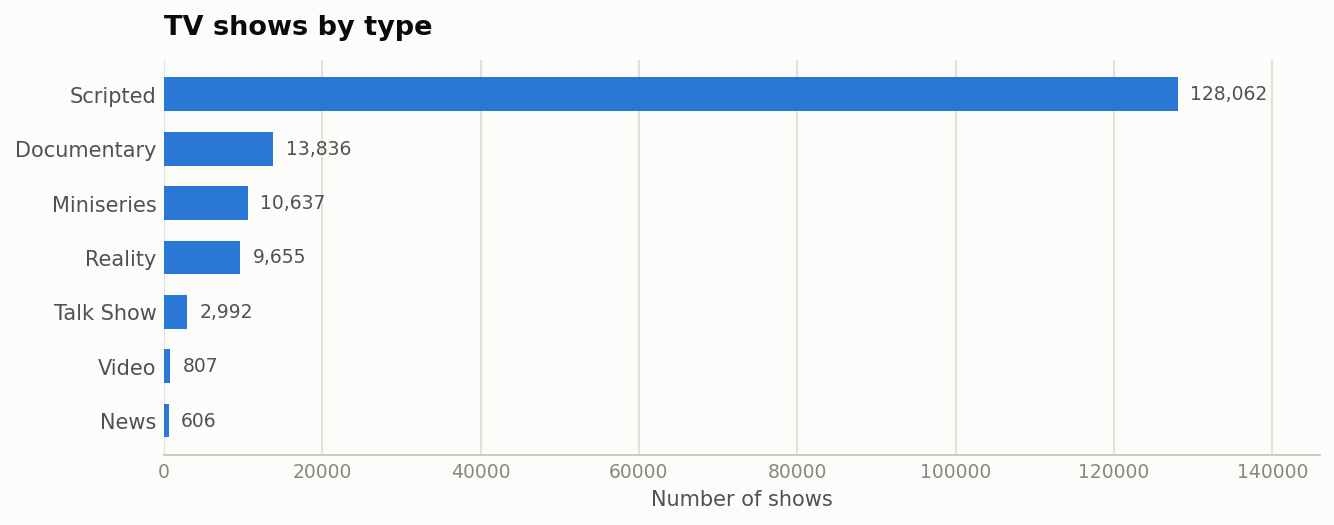

In [7]:
type_counts = df["type"].value_counts()
bar_distribution(type_counts, "TV shows by type")
plt.show()

### `genres` — one bar per genre

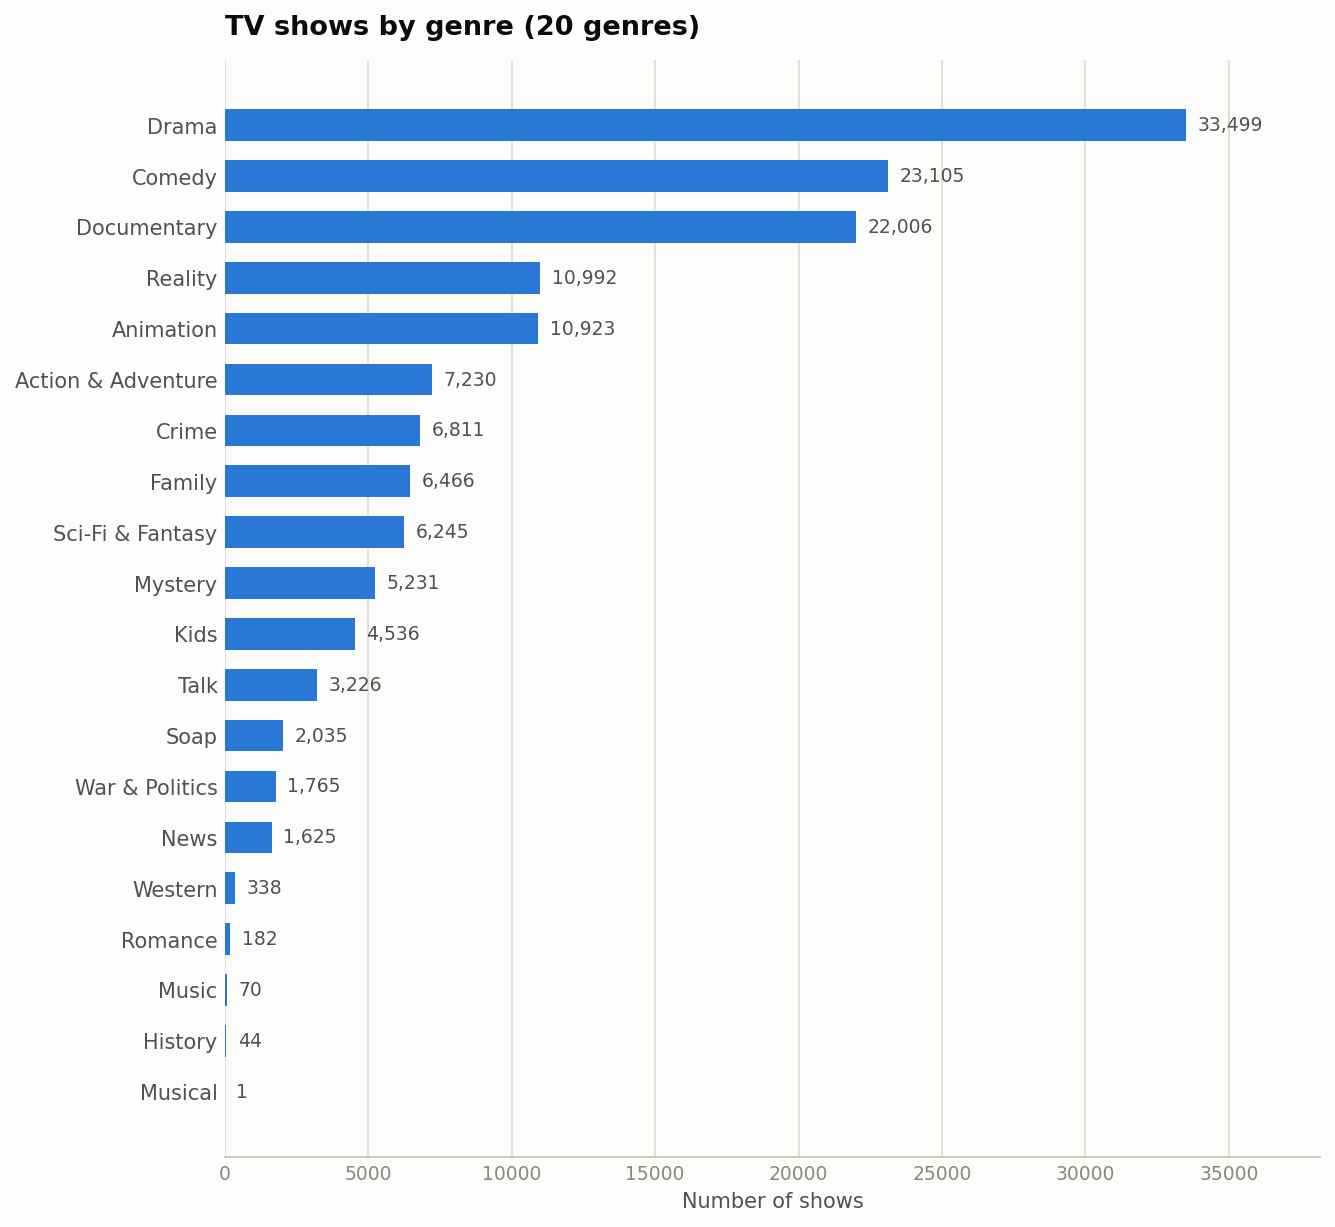

In [8]:
individual_genres = df["genres"].dropna().str.split(", ").explode().value_counts()
bar_distribution(individual_genres, f"TV shows by genre ({len(individual_genres)} genres)")
plt.show()

### `genres` — one bar per unique genre combination

The raw `genres` field is multi-label (e.g. `"Drama, Comedy"`), so there are thousands of distinct combinations. Showing all of them would be unreadable, so this plots the top 20 combinations and folds the rest into "Other."

2,222 unique genre combinations total; showing top 20.


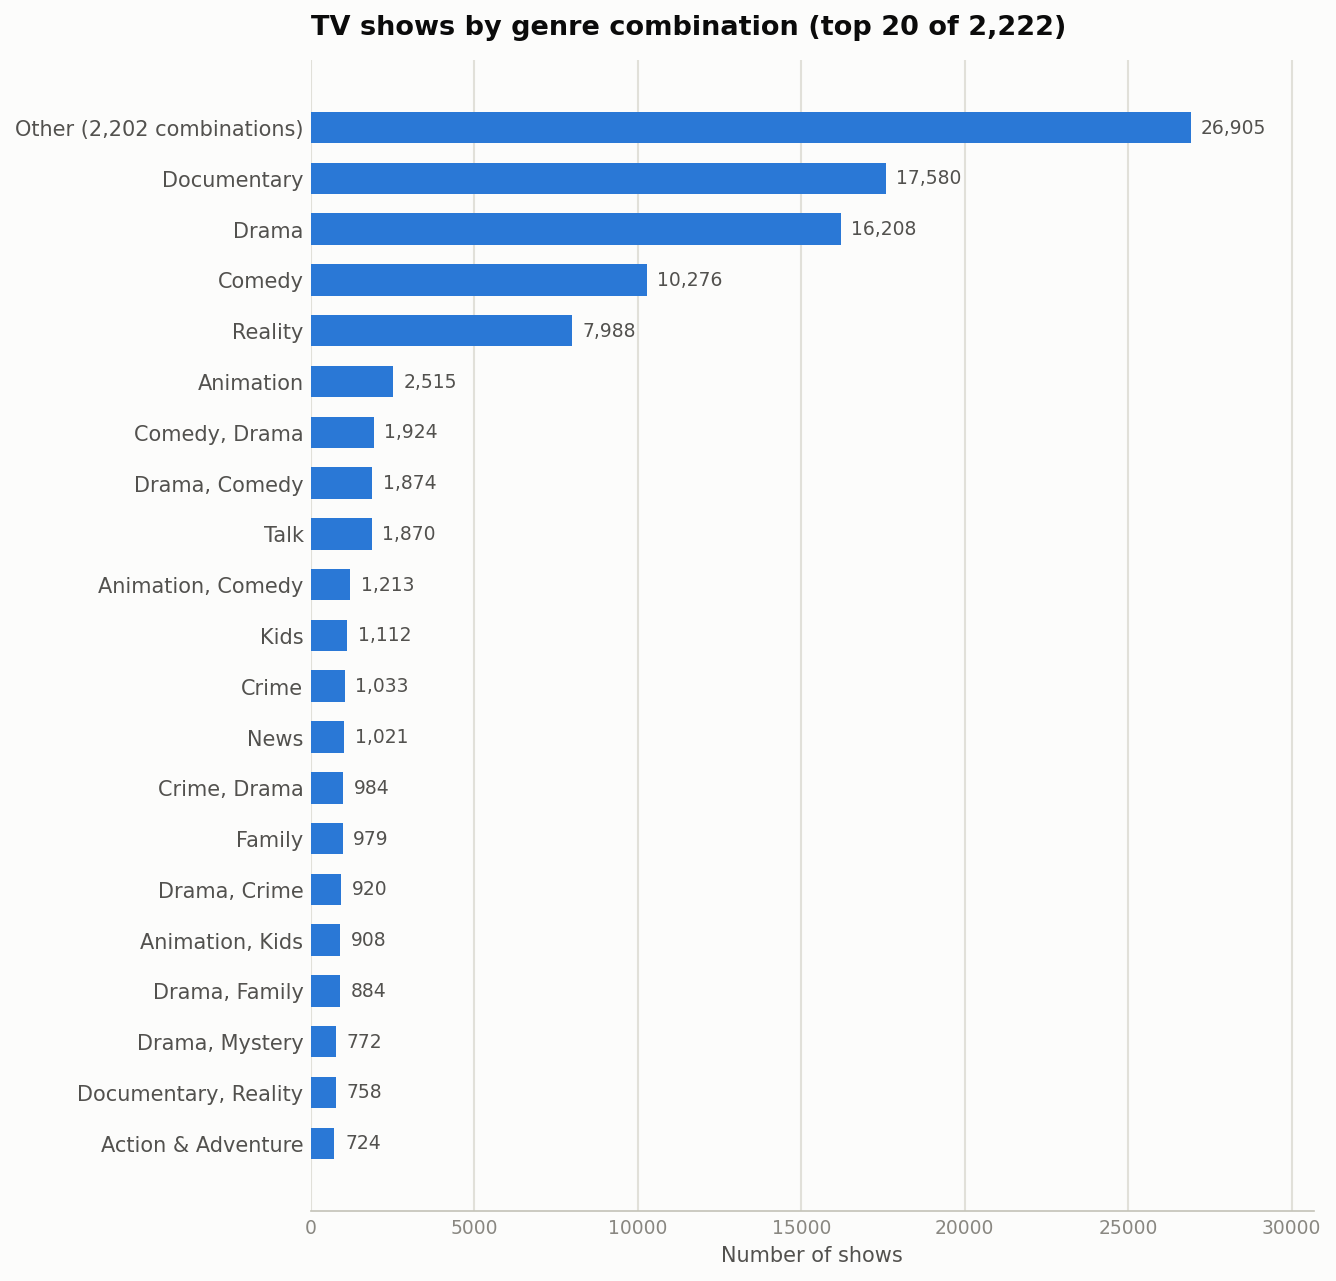

In [9]:
genre_combo_counts = df["genres"].dropna().value_counts()
top_combos = genre_combo_counts.head(TOP_N).copy()
other_n = len(genre_combo_counts) - TOP_N
other_total = genre_combo_counts.iloc[TOP_N:].sum()
if other_total > 0:
    top_combos[f"Other ({other_n:,} combinations)"] = other_total

print(f"{len(genre_combo_counts):,} unique genre combinations total; showing top {TOP_N}.")
bar_distribution(top_combos, f"TV shows by genre combination (top {TOP_N} of {len(genre_combo_counts):,})")
plt.show()

### `networks`

`networks` is also multi-value per show, with thousands of distinct networks. Exploded to one network per row, showing the top 20 by show count and folding the rest into "Other."

3,435 unique networks total; showing top 20.


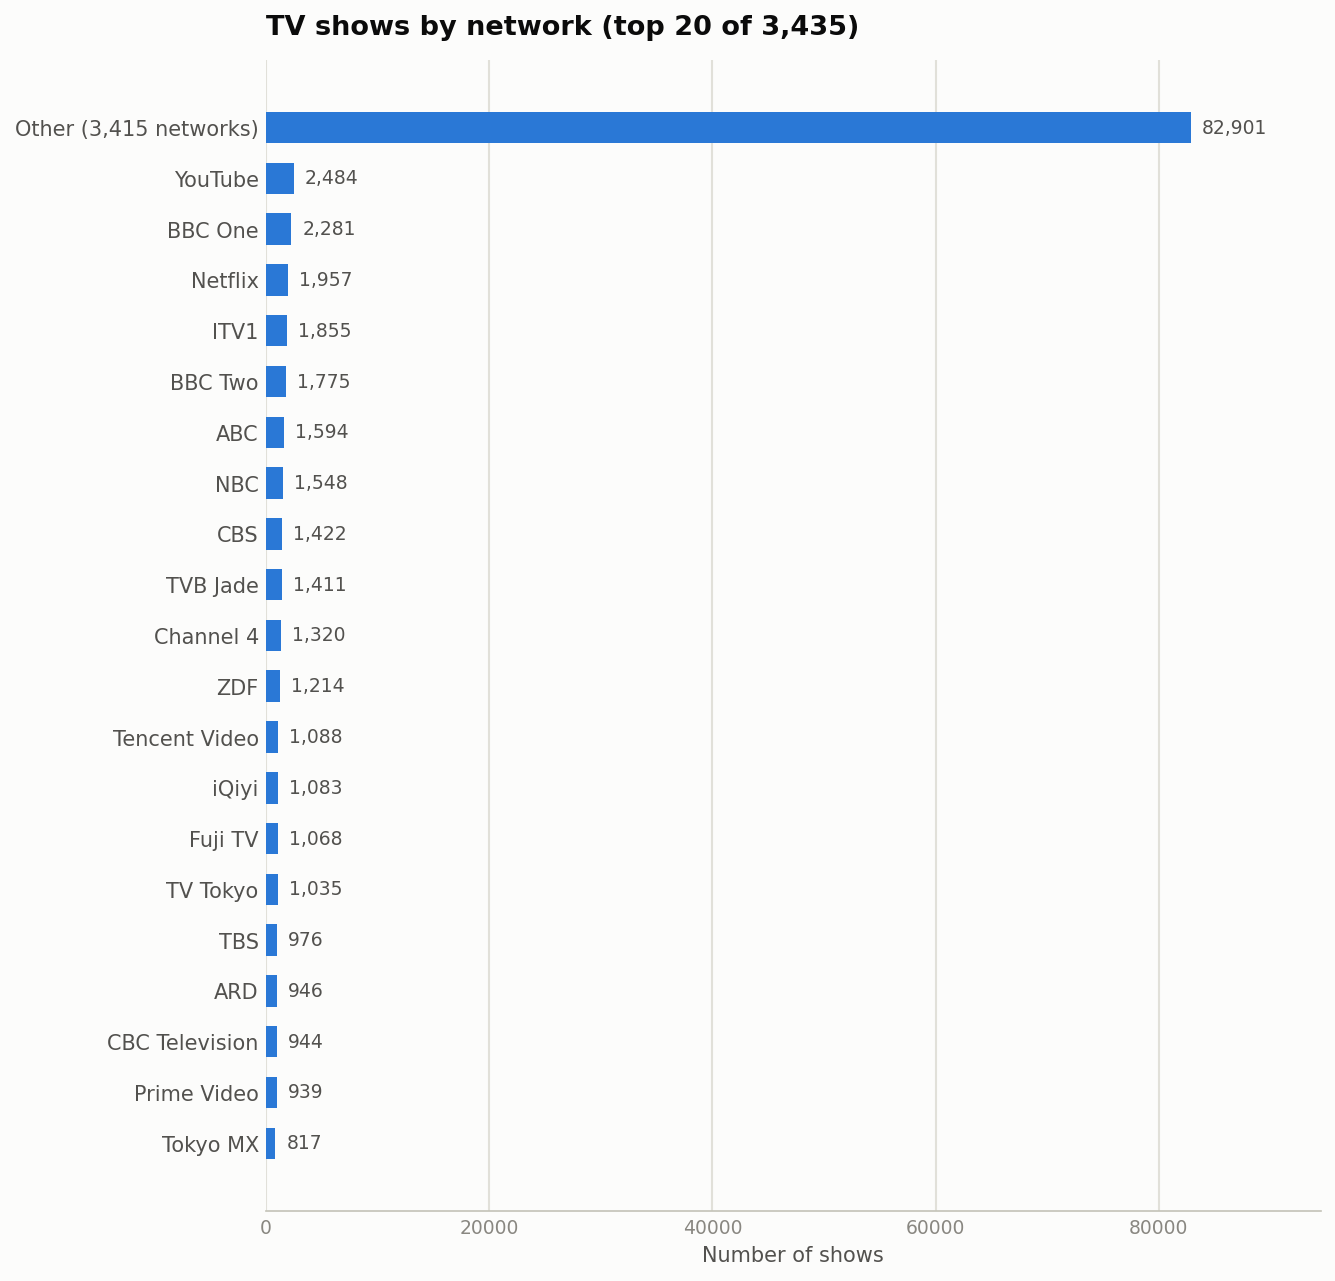

In [10]:
individual_networks = df["networks"].dropna().str.split(", ").explode().value_counts()
top_networks = individual_networks.head(TOP_N).copy()
other_n = len(individual_networks) - TOP_N
other_total = individual_networks.iloc[TOP_N:].sum()
if other_total > 0:
    top_networks[f"Other ({other_n:,} networks)"] = other_total

print(f"{len(individual_networks):,} unique networks total; showing top {TOP_N}.")
bar_distribution(top_networks, f"TV shows by network (top {TOP_N} of {len(individual_networks):,})")
plt.show()

## Netflix subset

A separate dataset of just the shows carried on Netflix (exact token match on the multi-value `networks` field, so `"Netflix, Hulu"` counts but a hypothetical `"Netflix Family"` network would not).

In [11]:
is_netflix = df["networks"].apply(lambda x: isinstance(x, str) and "Netflix" in x.split(", "))
netflix_df = df[is_netflix].reset_index(drop=True)
netflix_df.to_csv("netflix_shows.csv", index=False)

print(f"{len(netflix_df):,} Netflix shows out of {len(df):,} total ({len(netflix_df) / len(df):.1%})")
print("Saved to netflix_shows.csv")

1,957 Netflix shows out of 166,595 total (1.2%)
Saved to netflix_shows.csv


### `first_air_date` distribution — Netflix shows

Date range: 1993-2024
163 Netflix shows have no first_air_date (excluded from the chart)


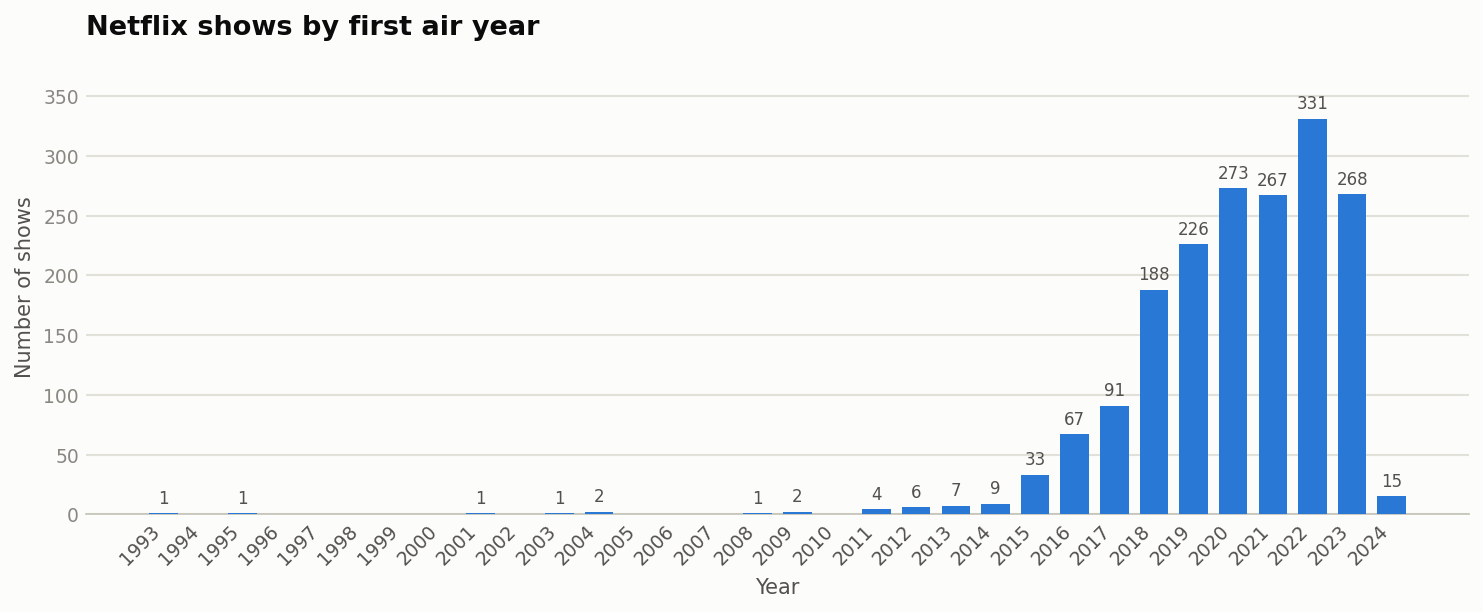

In [12]:
def column_distribution(counts, title, ylabel="Number of shows", xlabel=None, width=10, height=4.2):
    """Vertical bar chart over an ordered axis (e.g. year) — chronological order,
    not sorted by magnitude, single hue."""
    fig, ax = plt.subplots(figsize=(width, height))
    x = range(len(counts))
    bars = ax.bar(x, counts.values, width=0.72, color=BAR_COLOR, zorder=3)
    ax.set_xticks(list(x))
    ax.set_xticklabels(counts.index.astype(str), rotation=45, ha="right")

    ax.set_title(title, color=INK_PRIMARY, fontsize=13, loc="left", pad=12, weight="bold")
    ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=10)
    if xlabel:
        ax.set_xlabel(xlabel, color=INK_SECONDARY, fontsize=10)

    ax.tick_params(axis="x", colors=INK_SECONDARY, labelsize=9, length=0)
    ax.tick_params(axis="y", colors=INK_MUTED, labelsize=9, length=0)

    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.xaxis.grid(False)

    max_val = counts.values.max()
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_val * 0.015,
                    f"{val:,}", ha="center", va="bottom", fontsize=8, color=INK_SECONDARY)

    ax.set_ylim(0, max_val * 1.15)
    fig.tight_layout()
    return fig, ax


dates = pd.to_datetime(netflix_df["first_air_date"], errors="coerce")
missing = dates.isna().sum()
year_counts_sparse = dates.dt.year.dropna().astype(int).value_counts().sort_index()

# fill in years with zero shows so the x-axis spacing stays honest (no silent gaps)
full_years = range(year_counts_sparse.index.min(), year_counts_sparse.index.max() + 1)
year_counts = year_counts_sparse.reindex(full_years, fill_value=0)

print(f"Date range: {int(year_counts.index.min())}-{int(year_counts.index.max())}")
print(f"{missing} Netflix shows have no first_air_date (excluded from the chart)")

column_distribution(year_counts, "Netflix shows by first air year", xlabel="Year")
plt.show()

## Vote & date distributions

### 1. `vote_count` distribution — Netflix shows

`vote_count` is heavily right-skewed (most shows have very few votes, a handful have thousands), so this is plotted on a log1p x-axis with tick labels converted back to raw vote counts.

Netflix vote_count -- median: 20, mean: 192.0, max: 17,836, zero votes: 244 of 1957 (12.5%)


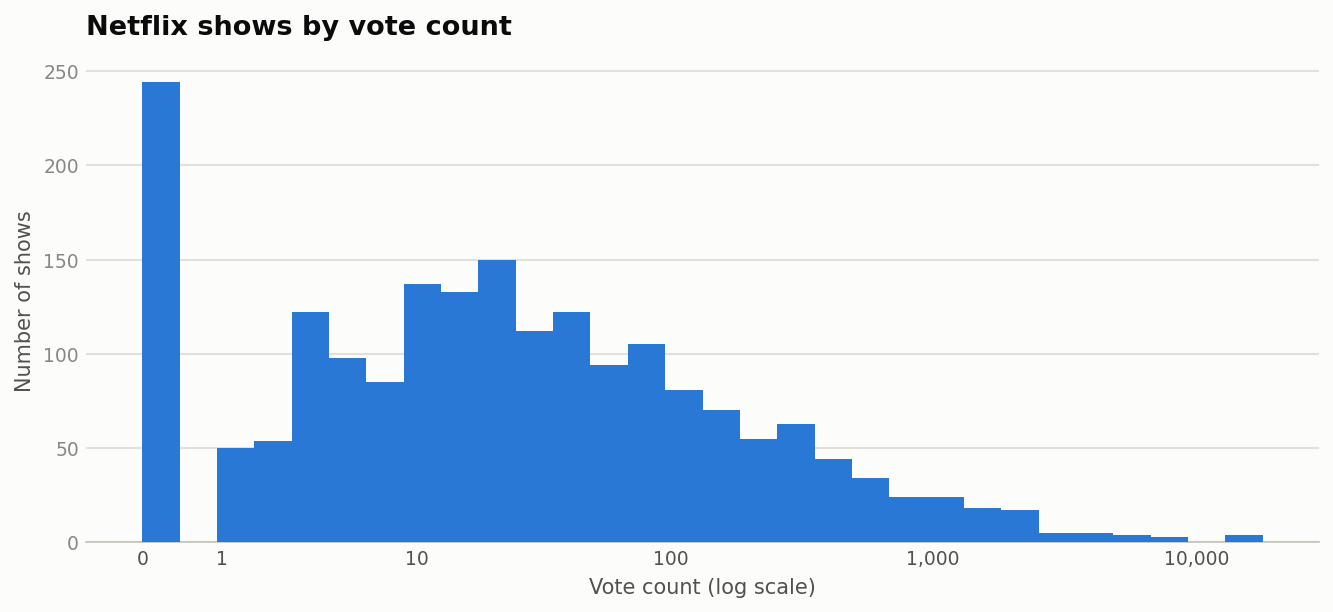

In [13]:
import numpy as np

def vote_count_histogram(vote_counts, title, bins=30, width=9, height=4.2):
    """Histogram of a heavily right-skewed count variable, log1p-transformed on x
    so the shape is readable; tick labels are shown in the original vote_count units."""
    values = vote_counts.values.astype(float)
    log_values = np.log1p(values)

    fig, ax = plt.subplots(figsize=(width, height))
    ax.hist(log_values, bins=bins, color=BAR_COLOR, zorder=3)

    ax.set_title(title, color=INK_PRIMARY, fontsize=13, loc="left", pad=12, weight="bold")
    ax.set_ylabel("Number of shows", color=INK_SECONDARY, fontsize=10)
    ax.set_xlabel("Vote count (log scale)", color=INK_SECONDARY, fontsize=10)

    tick_vals = [t for t in [0, 1, 10, 100, 1000, 10000] if t <= values.max()]
    ax.set_xticks(np.log1p(tick_vals))
    ax.set_xticklabels([f"{t:,}" for t in tick_vals])

    ax.tick_params(axis="x", colors=INK_SECONDARY, labelsize=9, length=0)
    ax.tick_params(axis="y", colors=INK_MUTED, labelsize=9, length=0)

    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.xaxis.grid(False)

    fig.tight_layout()
    return fig, ax


print(f"Netflix vote_count -- median: {netflix_df['vote_count'].median():.0f}, "
      f"mean: {netflix_df['vote_count'].mean():.1f}, max: {netflix_df['vote_count'].max():,}, "
      f"zero votes: {(netflix_df['vote_count'] == 0).sum()} of {len(netflix_df)} "
      f"({(netflix_df['vote_count'] == 0).mean():.1%})")

vote_count_histogram(netflix_df["vote_count"], "Netflix shows by vote count")
plt.show()

## NBC subset

Same exact-token approach as Netflix — this excludes lookalike networks that just contain "NBC" as a substring (CNBC, MSNBC, KNBC, NBC Weather Plus, NBCSN, etc.), keeping only shows where `"NBC"` is its own entry in the `networks` list.

In [14]:
is_nbc = df["networks"].apply(lambda x: isinstance(x, str) and "NBC" in x.split(", "))
nbc_df = df[is_nbc].reset_index(drop=True)

before = len(nbc_df)
dupe_ids = nbc_df["id"].duplicated().sum()
nbc_df = nbc_df.drop_duplicates(subset="id").reset_index(drop=True)

nbc_df.to_csv("nbc_shows.csv", index=False)

print(f"{before:,} NBC shows before dedup; removed {dupe_ids} duplicate id row(s)")
print(f"{len(nbc_df):,} NBC shows out of {len(df):,} total ({len(nbc_df) / len(df):.1%})")
print("Saved to nbc_shows.csv")

1,548 NBC shows before dedup; removed 4 duplicate id row(s)
1,544 NBC shows out of 166,595 total (0.9%)
Saved to nbc_shows.csv


### 2. `first_air_date` distribution — NBC shows

NBC's catalog spans 80+ years (vs. Netflix's ~10), so this chart thins the x-axis tick labels to every 5th year and drops per-bar value labels (too many bars to label individually) — the peak year is called out directly instead.

Date range: 1944-2024
45 NBC shows have no first_air_date (excluded from the chart)


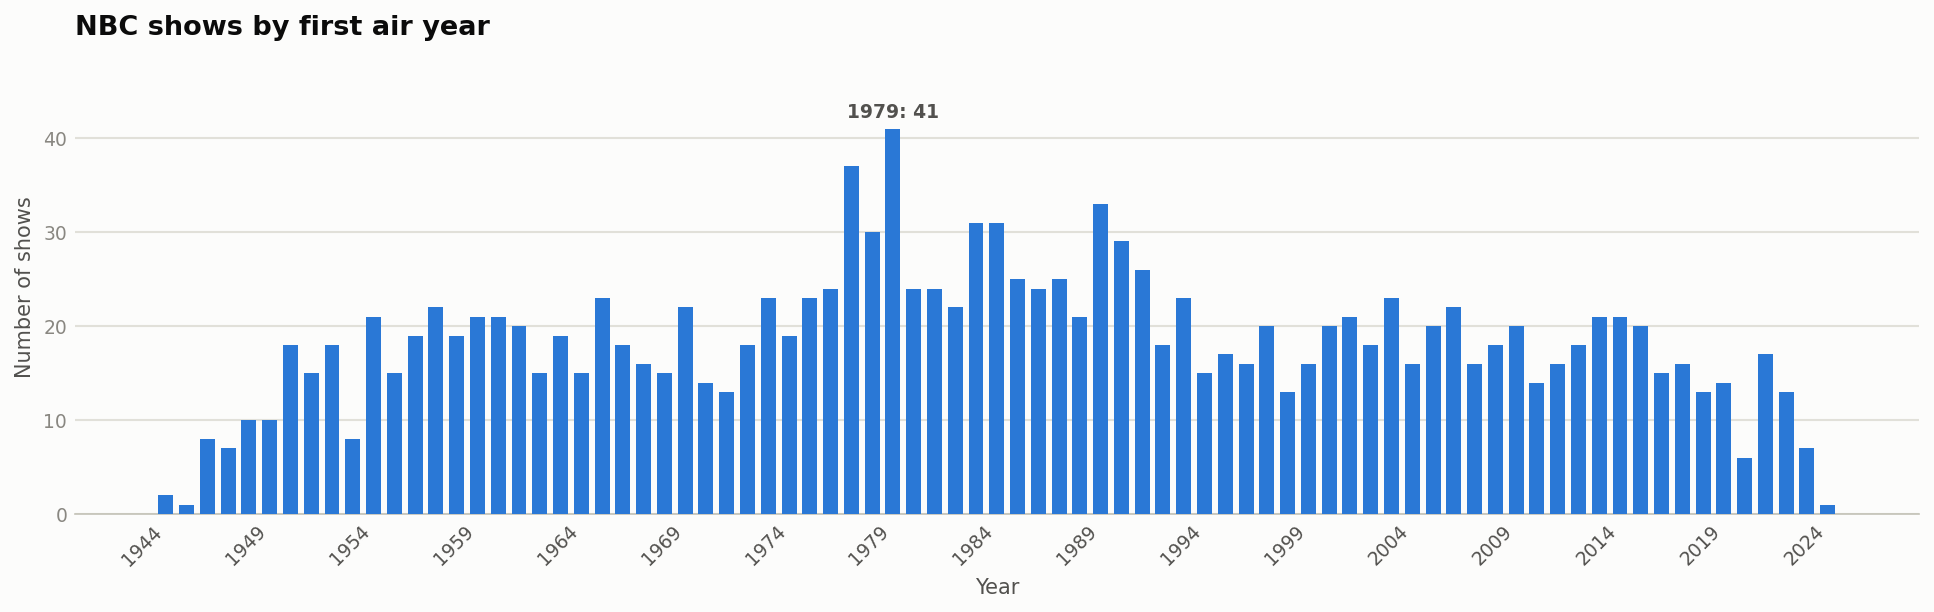

In [15]:
def column_distribution(counts, title, ylabel="Number of shows", xlabel=None,
                         width=10, height=4.2, tick_step=1, label_peak_only=False):
    """Vertical bar chart over an ordered axis (e.g. year) — chronological order,
    not sorted by magnitude, single hue. tick_step thins x-axis labels for long
    ranges; label_peak_only calls out just the highest bar instead of every bar."""
    fig, ax = plt.subplots(figsize=(width, height))
    x = list(range(len(counts)))
    bars = ax.bar(x, counts.values, width=0.72, color=BAR_COLOR, zorder=3)

    ax.set_xticks(x[::tick_step])
    ax.set_xticklabels(counts.index.astype(str)[::tick_step], rotation=45, ha="right")

    ax.set_title(title, color=INK_PRIMARY, fontsize=13, loc="left", pad=12, weight="bold")
    ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=10)
    if xlabel:
        ax.set_xlabel(xlabel, color=INK_SECONDARY, fontsize=10)

    ax.tick_params(axis="x", colors=INK_SECONDARY, labelsize=9, length=0)
    ax.tick_params(axis="y", colors=INK_MUTED, labelsize=9, length=0)

    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.xaxis.grid(False)

    max_val = counts.values.max()
    if label_peak_only:
        peak_i = int(counts.values.argmax())
        bar = bars[peak_i]
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_val * 0.02,
                f"{counts.index[peak_i]}: {int(counts.values[peak_i]):,}",
                ha="center", va="bottom", fontsize=9, color=INK_SECONDARY, weight="bold")
    else:
        for bar, val in zip(bars, counts.values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_val * 0.015,
                        f"{val:,}", ha="center", va="bottom", fontsize=8, color=INK_SECONDARY)

    ax.set_ylim(0, max_val * 1.18)
    fig.tight_layout()
    return fig, ax


nbc_dates = pd.to_datetime(nbc_df["first_air_date"], errors="coerce")
nbc_missing = nbc_dates.isna().sum()
nbc_year_counts_sparse = nbc_dates.dt.year.dropna().astype(int).value_counts().sort_index()

full_years = range(nbc_year_counts_sparse.index.min(), nbc_year_counts_sparse.index.max() + 1)
nbc_year_counts = nbc_year_counts_sparse.reindex(full_years, fill_value=0)

print(f"Date range: {int(nbc_year_counts.index.min())}-{int(nbc_year_counts.index.max())}")
print(f"{nbc_missing} NBC shows have no first_air_date (excluded from the chart)")

column_distribution(nbc_year_counts, "NBC shows by first air year", xlabel="Year",
                     width=13, tick_step=5, label_peak_only=True)
plt.show()

### 3. `vote_count` distribution — NBC shows

NBC vote_count -- median: 2, mean: 62.0, max: 7,192, zero votes: 430 of 1544 (27.8%)


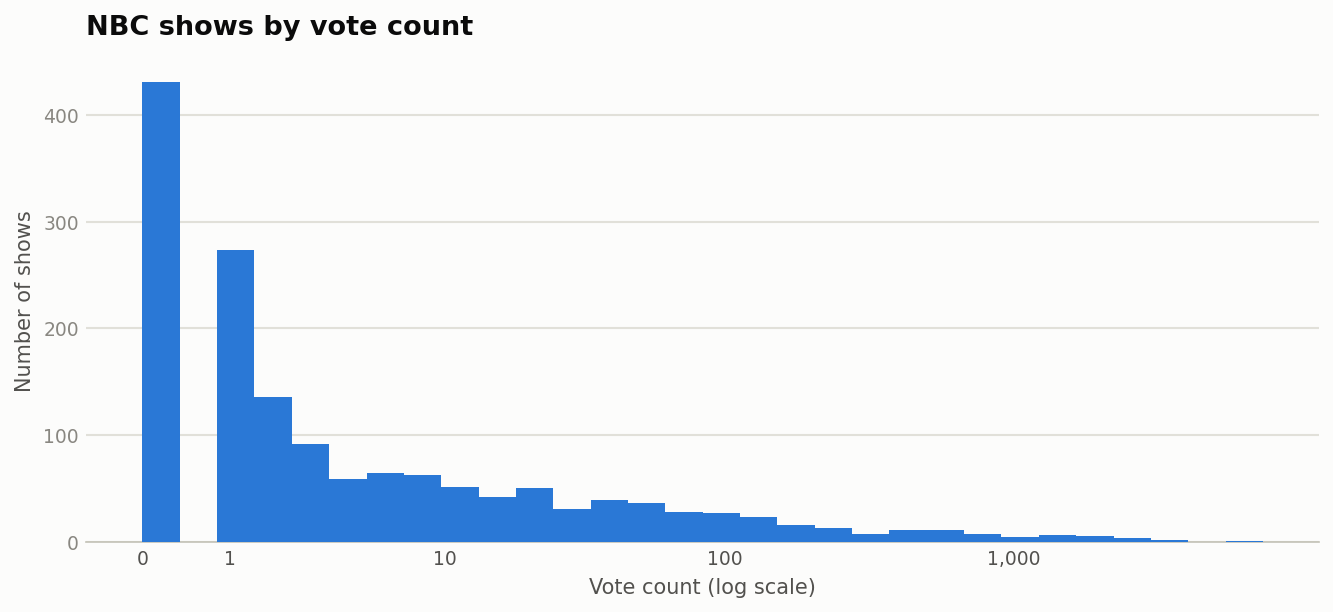

In [16]:
print(f"NBC vote_count -- median: {nbc_df['vote_count'].median():.0f}, "
      f"mean: {nbc_df['vote_count'].mean():.1f}, max: {nbc_df['vote_count'].max():,}, "
      f"zero votes: {(nbc_df['vote_count'] == 0).sum()} of {len(nbc_df)} "
      f"({(nbc_df['vote_count'] == 0).mean():.1%})")

vote_count_histogram(nbc_df["vote_count"], "NBC shows by vote count")
plt.show()

### Top 10 NBC shows by vote count

In [17]:
top10_nbc = nbc_df.nlargest(10, "vote_count")[["name", "first_air_date", "vote_count", "vote_average"]]
top10_nbc

,name,first_air_date,vote_count,vote_average
0,Friends,1994-09-22,7192,8.444
1,The Office,2005-03-24,3443,8.587
2,Law & Order: Special Victims Unit,1999-09-20,3389,7.962
3,Brooklyn Nine-Nine,2013-09-17,2875,8.236
4,Grimm,2011-10-28,2869,8.283
5,The Blacklist,2013-09-23,2834,7.619
6,Blindspot,2015-09-21,2293,7.378
7,Chicago P.D.,2014-01-08,2186,8.453
8,Hannibal,2013-04-04,2121,8.230
9,The Fresh Prince of Bel-Air,1990-09-10,2056,7.955


### 10 most recently created NBC shows

Note: found 4 duplicate `id` rows within `nbc_df` while building this (one show, "Mutual of Omaha's Wild Kingdom Protecting the Wild", is an exact duplicate row) — deduplicated by `id` here so it doesn't double-count. The full dataset has 3,896 duplicate `id` rows overall, which is worth a dedup pass as a cleaning step.

In [18]:
nbc_dated = nbc_df.dropna(subset=["first_air_date"]).copy()
nbc_dated["_date"] = pd.to_datetime(nbc_dated["first_air_date"], errors="coerce")
nbc_dated = nbc_dated.dropna(subset=["_date"])

most_recent_nbc = nbc_dated.nlargest(10, "_date")[["name", "first_air_date", "vote_count", "vote_average"]]
most_recent_nbc

,name,first_air_date,vote_count,vote_average
1148,AGT: Fantasy League,2024-01-31,0,0.0
1423,Mutual of Omaha's Wild Kingdom Protecting the ...,2023-10-07,0,0.0
724,Found,2023-10-03,2,6.0
415,The Irrational,2023-09-25,10,8.9
674,LA Fire & Rescue,2023-06-21,3,9.0
817,Hot Wheels: Ultimate Challenge,2023-05-30,2,5.5
295,Night Court,2023-01-17,22,7.0
564,America's Got Talent: All-Stars,2023-01-02,4,6.5
607,The Wheel,2022-12-19,4,4.5
494,Lopez vs Lopez,2022-11-04,6,8.2


## NBC distributions: `type` and `genres`

### `type` — NBC shows

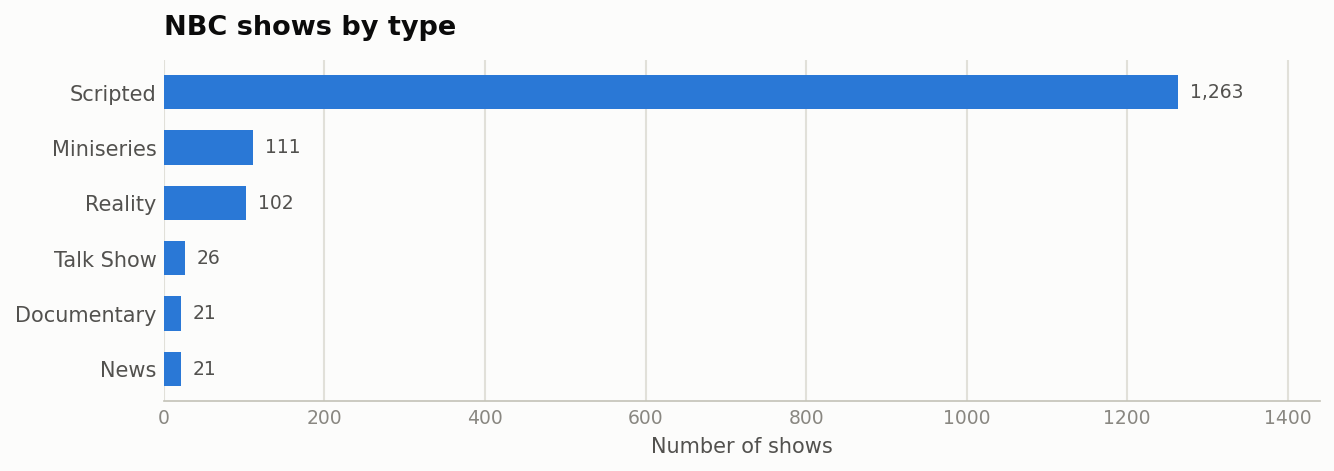

In [19]:
nbc_type_counts = nbc_df["type"].value_counts()
bar_distribution(nbc_type_counts, "NBC shows by type")
plt.show()

### `genres` — one bar per genre — NBC shows

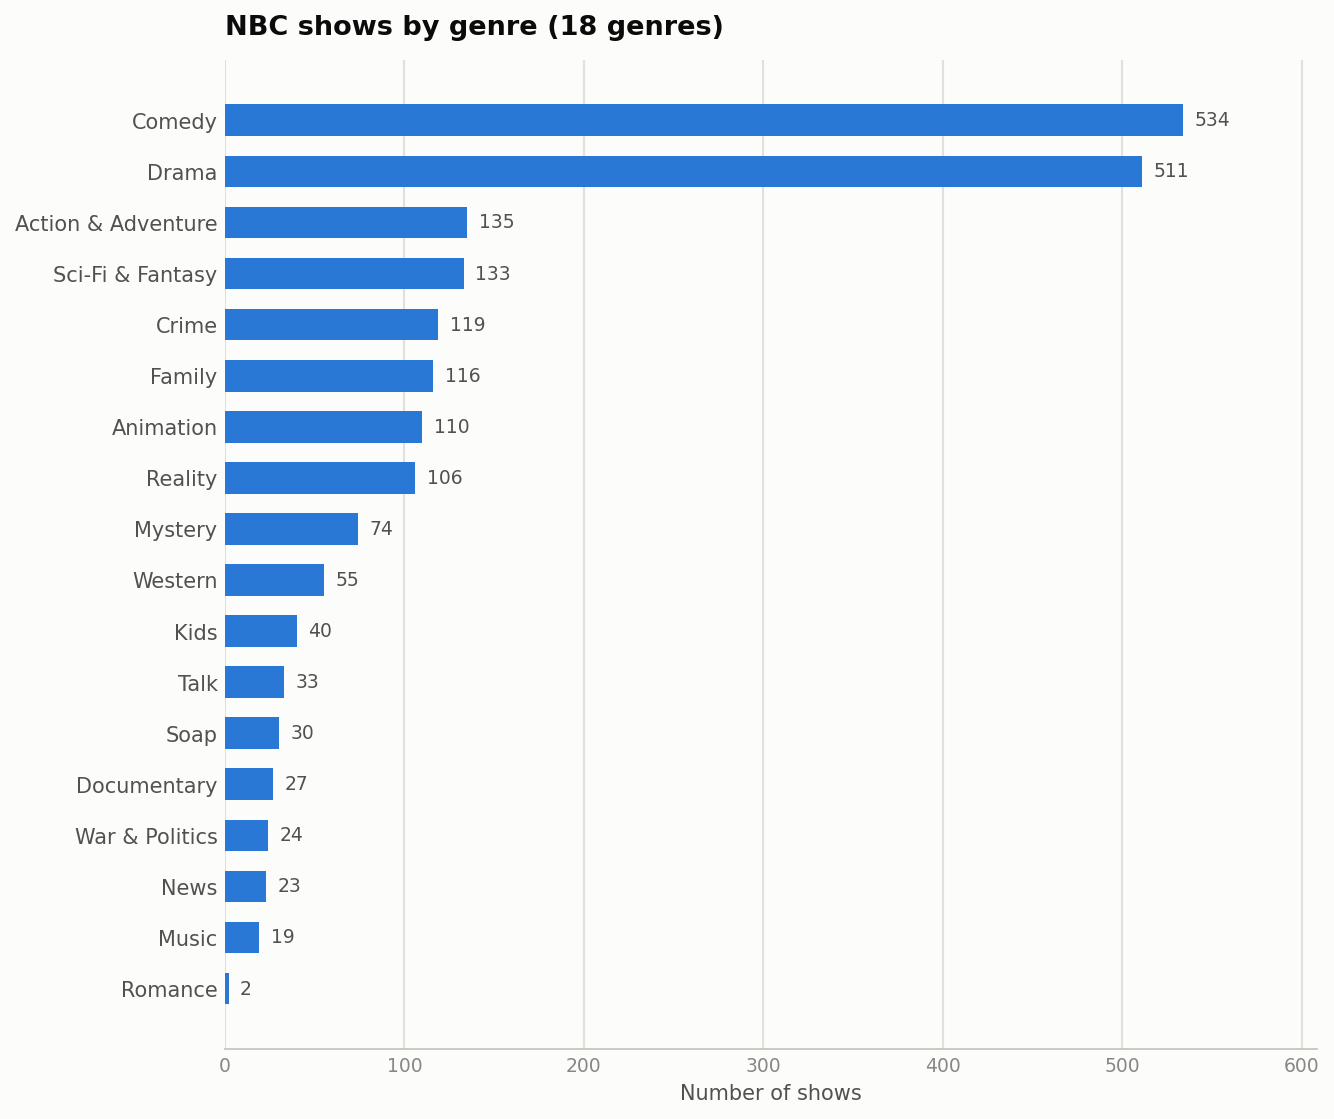

In [20]:
nbc_individual_genres = nbc_df["genres"].dropna().str.split(", ").explode().value_counts()
bar_distribution(nbc_individual_genres, f"NBC shows by genre ({len(nbc_individual_genres)} genres)")
plt.show()

## Decision: filtering the dataset to NBC shows

After exploring several network subsets, I've settled on filtering the full cleaned dataset down to just **NBC shows** as the working set for the rest of this project. The reasoning, with the numbers behind it:

**Size.** The NBC subset (deduplicated by `id`) is 1,544 shows out of 166,595 in the cleaned dataset (0.9%) — small enough to work with quickly, large enough to synthesize a meaningful user/friend population against.

**Strong variety of types.** NBC shows span all 6 `type` values present in the dataset, not just one or two:

| Type | Count |
|---|---|
| Scripted | 1,263 |
| Miniseries | 111 |
| Reality | 102 |
| Talk Show | 26 |
| News | 21 |
| Documentary | 21 |

**Strong variety of genres.** Exploding the multi-label `genres` field gives 18 distinct individual genres represented in the NBC catalog (out of 20 genres in the full dataset) — everything from Comedy and Drama down to Western, Music, and Romance:

| Genre | Count | | Genre | Count |
|---|---|---|---|---|
| Comedy | 534 | | Kids | 40 |
| Drama | 511 | | Talk | 33 |
| Action & Adventure | 135 | | Soap | 30 |
| Sci-Fi & Fantasy | 133 | | Documentary | 27 |
| Crime | 119 | | War & Politics | 24 |
| Family | 116 | | News | 23 |
| Animation | 110 | | Music | 19 |
| Reality | 106 | | Romance | 2 |
| Mystery | 74 | | | |
| Western | 55 | | | |

Comedy and Drama lead (534 and 511 respectively), but unlike some networks whose catalog is dominated by one or two genres, NBC has meaningful representation across nearly a dozen genres before the counts trail off.

**Most shows have votes.** Of the 1,544 NBC shows, 1,114 (72.2%) have at least one vote recorded (`vote_count` > 0), leaving only 430 (27.8%) with zero votes — a real base of engagement signal to synthesize viewing behavior against, unlike sparser networks where the majority of shows have no votes at all. Median `vote_count` is 2 and mean is 62.0 (pulled up by outliers like *Friends* at 7,192 votes), and `vote_average` is populated for the same voted subset, giving a genuine quality/rating signal to lean on.